<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Planulae_Oxygen_Consumption_Rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Block 1: Imports and File Loading
This block imports the necessary libraries and loads your raw data.

files that need to uploaded:
1. original output of the SDR progrem (.xlsx)
2. loadout map of what sample in each well (.xslx)


In [33]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Define file paths (Update these if you rename the files in Colab)
oxy_file = 'oxy16042026_Oxygen.xlsx'
loadout_file = 'loadout.xlsx'

# Load the plate map (loadout)
# We assume the first column is the row letters (A, B, C, D)
# and columns 1-6 are the well numbers.
loadout_df = pd.read_excel(loadout_file)

# Load the Oxygen data
# We search for the row containing "Time/Min." to skip the PreSens metadata
# Read the Excel file initially without a header to find the row containing "Time/Min."
temp_df = pd.read_excel(oxy_file, header=None)

# Find the row index that contains "Time/Min."
header_row_idx = None
for i, row in temp_df.iterrows():
    # Check if 'Time/Min.' (or similar string, in case of slight variations) is in any cell of the row
    if any(isinstance(cell, str) and "Time/Min." in cell for cell in row.values):
        header_row_idx = i
        break

if header_row_idx is None:
    raise ValueError("Could not find 'Time/Min.' header in the Oxygen data file.")

# Load the actual data using the identified header row
oxy_raw = pd.read_excel(oxy_file, header=header_row_idx)
oxy_raw.columns = [c.strip() for c in oxy_raw.columns] # Clean column names

print(f"Data loaded. Found {len(oxy_raw)} timepoints.")

Data loaded. Found 271 timepoints.


#Block 2: Mapping Well IDs to Morphs
This block transforms your plate map into a dictionary so the code knows which well contains HF, NF, or a Blank.

In [34]:
# Create a mapping dictionary {Well: Morph}
well_map = {}
for i, row in loadout_df.iterrows():
    row_letter = row['Unnamed: 0'] # Usually 'A', 'B', etc.
    for col_idx in range(1, 7): # Columns 1 through 6
        well_id = f"{row_letter}{col_idx}"
        morph_label = row[col_idx]
        well_map[well_id] = morph_label

print("Well Map Created:")
for well, morph in well_map.items():
    print(f"{well}: {morph}", end=" | ")

Well Map Created:
A1: HF | A2: HF | A3: HF | A4: NF | A5: NF | A6: blank | B1: HF | B2: HF | B3: HF | B4: NF | B5: NF | B6: blank | C1: HF | C2: HF | C3: NF | C4: NF | C5: NF | C6: blank | D1: HF | D2: HF | D3: NF | D4: NF | D5: NF | D6: blank | 

# Block 3: Calculating Slopes and Blank Correction
This block performs the linear regression for every well and calculates the average "Zero" baseline from all 4 blanks (A6, B6, C6, D6).

In [35]:
results = []
time = oxy_raw['Time/Min.'].values

# 1. Calculate raw slopes for every well in the map
for well, morph in well_map.items():
    if well in oxy_raw.columns:
        y_values = oxy_raw[well].values
        # Remove NaNs if any
        mask = ~np.isnan(y_values)
        slope, intercept, r_value, p_value, std_err = stats.linregress(time[mask], y_values[mask])

        results.append({
            'Well': well,
            'Morph': morph,
            'Slope_umol_L_min': slope,
            'R_squared': r_value**2
        })

df_results = pd.DataFrame(results)

# 2. Calculate the Average Blank Rate (includes all positive/negative noise)
avg_blank = df_results[df_results['Morph'] == 'blank']['Slope_umol_L_min'].mean()

# 3. Correct the slopes (Well Slope - Avg Blank)
df_results['Corrected_Slope'] = df_results['Slope_umol_L_min'] - avg_blank

print(f"Average Blank Rate (Background Drift): {avg_blank:.5f} umol/L/min")
df_results[['Well', 'Morph', 'Slope_umol_L_min', 'Corrected_Slope']].head()

Average Blank Rate (Background Drift): -0.00223 umol/L/min


,Well,Morph,Slope_umol_L_min,Corrected_Slope
0,A1,HF,-0.404921,-0.402695
1,A2,HF,-1.013406,-1.011180
2,A3,HF,-1.144284,-1.142058
3,A4,NF,-1.598505,-1.596278
4,A5,NF,-1.862354,-1.860127


# Block 4: Volume Normalization
This is where we apply your specific volumes (HF: 0.3024 and NF: 0.2698) and the 3 larvae per well count to get the final units: $nmol \, O_2 / mm^3 / min$.

In [36]:
# Constants for normalization
HF_VOL = 0.3024
NF_VOL = 0.2698
WELL_VOL_ML = 0.080 # 80 microliters = 0.080 mL
LARVAE_PER_WELL = 3

def calculate_nmol_mm3_min(row):
    if row['Morph'] == 'blank':
        return np.nan

    # Select the correct volume based on morph
    vol = HF_VOL if row['Morph'] == 'HF' else NF_VOL

    # Formula: |Corrected Slope| * Well Volume / (Larvae count * Individual Volume)
    # ABS is used because we want the consumption rate as a positive value
    rate = (abs(row['Corrected_Slope']) * WELL_VOL_ML) / (LARVAE_PER_WELL * vol)
    return rate

df_results['nmol_O2_mm3_min'] = df_results.apply(calculate_nmol_mm3_min, axis=1)

# Summary Stats
summary = df_results.dropna().groupby('Morph')['nmol_O2_mm3_min'].agg(['mean', 'std', 'count'])
print("\nFinal Respiration Rates (nmol O2 / mm3 / min):")
print(summary)


Final Respiration Rates (nmol O2 / mm3 / min):
           mean       std  count
Morph                           
HF     0.132192  0.070953     10
NF     0.161564  0.058978     10


# Block 5: Outlier Removal & Normality-Based Stats
This block filters outliers using the 1.5x IQR method, checks for normality, and automatically runs either an Independent T-test (Parametric) or a Mann-Whitney U test (Non-Parametric).

### Global settings for plot

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 25,      # Global title padding
    "axes.labelsize": 12,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2
})

# --- GLOBAL TITLES & LABELS ---
global_main_title = "Morphotype Metabolic Cost"
global_x_label = "Morph"
global_y_label = "Respiration rate (nmol/mm$^3$/min)"

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

global_fig_size = (6, 6) # Reduced width for a slimmer plot
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6
global_box_width = 0.4 # New global setting for boxplot width

# Centralized Asterisk Settings
global_asterisk_size = 18
global_asterisk_weight = 'bold'

# Added for cleaner look
global_y_nbins = 3

print("Global styling and titles initialized.")

Global styling and titles initialized.


=== OUTLIER REMOVAL REPORT ===
Well Morph  nmol_O2_mm3_min
  A1    HF         0.035511
  C1    HF         0.276953
  C2    HF         0.233044
  C3    NF         0.289992




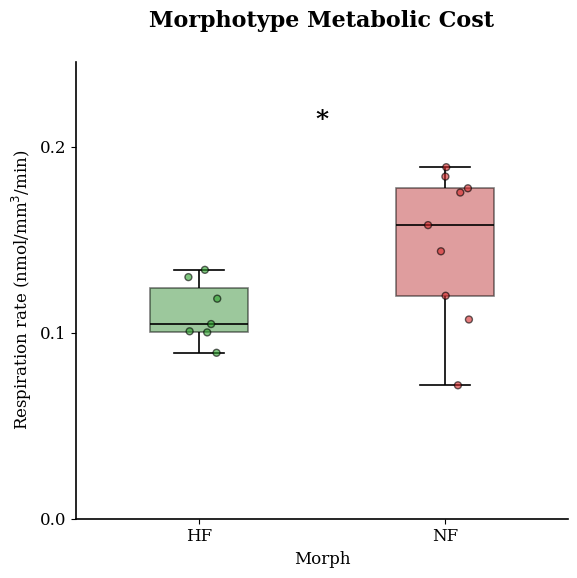

In [42]:
from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind
from matplotlib.ticker import MaxNLocator

# 1. Prepare data (exclude blanks)
df_clean = df_results[df_results['Morph'] != 'blank'].copy()

# 2. Outlier Detection (per group)
outliers_list = []
df_final_list = []

for morph in ['HF', 'NF']:
    group = df_clean[df_clean['Morph'] == morph].copy()
    q1 = group['nmol_O2_mm3_min'].quantile(0.25)
    q3 = group['nmol_O2_mm3_min'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    group_outliers = group[(group['nmol_O2_mm3_min'] < lower_bound) | (group['nmol_O2_mm3_min'] > upper_bound)]
    outliers_list.append(group_outliers)
    group_cleaned = group[(group['nmol_O2_mm3_min'] >= lower_bound) & (group['nmol_O2_mm3_min'] <= upper_bound)]
    df_final_list.append(group_cleaned)

df_outliers = pd.concat(outliers_list)
df_final = pd.concat(df_final_list)

# 3. Output Outlier Report
print("=== OUTLIER REMOVAL REPORT ===")
if not df_outliers.empty:
    print(df_outliers[['Well', 'Morph', 'nmol_O2_mm3_min']].to_string(index=False))
else:
    print("No outliers detected.")
print("\n")

# 4. Normality Check
hf_vals = df_final[df_final['Morph'] == 'HF']['nmol_O2_mm3_min']
nf_vals = df_final[df_final['Morph'] == 'NF']['nmol_O2_mm3_min']
stat_hf, p_hf = shapiro(hf_vals)
stat_nf, p_nf = shapiro(nf_vals)

# 5. Statistical Analysis
is_normal = (p_hf > 0.05) and (p_nf > 0.05)
if is_normal:
    _, p_levene = levene(hf_vals, nf_vals)
    t_stat, p_val = ttest_ind(hf_vals, nf_vals, equal_var=(p_levene > 0.05))
    test_name = "Independent T-test" if p_levene > 0.05 else "Welch's T-test"
else:
    u_stat, p_val = mannwhitneyu(hf_vals, nf_vals)
    test_name = "Mann-Whitney U test"

# 6. Poster Plot Generation
morph_order = ['HF', 'NF']
plt.figure(figsize=global_fig_size)

ax = sns.boxplot(
    data=df_final, x='Morph', y='nmol_O2_mm3_min', order=morph_order, hue='Morph', palette=variant_colors,
    width=global_box_width, showfliers=False, linewidth=plt.rcParams['axes.linewidth'], legend=False,
    boxprops=dict(edgecolor='black', alpha=0.5),
    whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black')
)

sns.stripplot(
    data=df_final, x='Morph', y='nmol_O2_mm3_min', order=morph_order, hue='Morph', palette=variant_colors,
    jitter=global_jitter, size=global_marker_size, linewidth=1, edgecolor='black',
    alpha=global_alpha, legend=False, zorder=3
)

# 7. SIGNIFICANCE ANNOTATION (Asterisk Only, Bracket Removed)
if p_val < 0.05:
    x1, x2 = 0, 1
    y_max = df_final['nmol_O2_mm3_min'].max()
    y_pos = y_max * 1.1

    # Display only the asterisk centered between groups
    plt.text((x1+x2)*.5, y_pos, "*", ha='center', va='bottom',
             fontsize=global_asterisk_size, fontweight=global_asterisk_weight, color='black')

plt.ylabel(global_y_label)
plt.xlabel(global_x_label)
plt.title(global_main_title)

plt.ylim(0, df_final['nmol_O2_mm3_min'].max() * 1.3)
ax.yaxis.set_major_locator(MaxNLocator(nbins=global_y_nbins))

sns.despine()
plt.tight_layout()

# FIXED: Save figure BEFORE calling plt.show()
plt.savefig('Planulae_Resperation_Rate.svg', dpi=600)
plt.show()

# Block 6: Detailed Statistical Reporting
Run this block to get a clean, copy-pasteable summary of your analysis.

In [39]:
# 1. Detailed Outlier Report
print("====================================================")
print("PHASE 1: OUTLIER REMOVAL (1.5x IQR Method)")
print("====================================================")
if not df_outliers.empty:
    # Formatting for clarity in the console
    report = df_outliers[['Well', 'Morph', 'nmol_O2_mm3_min']].copy()
    report.columns = ['Well ID', 'Morphology', 'Value (nmol/mm3/min)']
    print(report.to_string(index=False))
    print(f"\nTOTAL REMOVED: {len(df_outliers)} samples.")
else:
    print("No outliers detected. All data points retained.")

print("\n")

# 2. Normality Verification (Shapiro-Wilk)
print("====================================================")
print("PHASE 2: NORMALITY & VARIANCE DIAGNOSTICS")
print("====================================================")
print(f"HF Group (n={len(hf_vals)}): {'NORMAL' if p_hf > 0.05 else 'NON-NORMAL'} (p = {p_hf:.4f})")
print(f"NF Group (n={len(nf_vals)}): {'NORMAL' if p_nf > 0.05 else 'NON-NORMAL'} (p = {p_nf:.4f})")

# Check Variance for the paper
_, p_levene = levene(hf_vals, nf_vals)
print(f"Homogeneity of Variance: {'PASSED' if p_levene > 0.05 else 'FAILED'} (p = {p_levene:.4f})")

print("\n")

# 3. Final Manuscript Summary
print("====================================================")
print("PHASE 3: MANUSCRIPT RESULTS SUMMARY")
print("====================================================")
print(f"Statistical Test: {test_name}")
print(f"Final p-value:    {p_val:.4f}")
print(f"Significance:     {'Significant (p < 0.05)' if p_val < 0.05 else 'Not Significant'}")
print("----------------------------------------------------")

# Calculate means and SEM for the Results paragraph
hf_mean = hf_vals.mean()
hf_sem = hf_vals.sem()
nf_mean = nf_vals.mean()
nf_sem = nf_vals.sem()

print(f"HF Mean: {hf_mean:.4f} ± {hf_sem:.4f} SEM")
print(f"NF Mean: {nf_mean:.4f} ± {nf_sem:.4f} SEM")
print("====================================================")

# This formatted string is exactly what you should paste into your Results section
print("\n[SUGGESTED MANUSCRIPT TEXT]:")
print(f"Weight-specific metabolic demand was significantly lower in HF morphs "
      f"({hf_mean:.3f} ± {hf_sem:.3f} nmol O2 mm^-3 min^-1) compared to NF morphs "
      f"({nf_mean:.3f} ± {nf_sem:.3f} nmol O2 mm^-3 min^-1; {test_name}, p = {p_val:.4f}).")

PHASE 1: OUTLIER REMOVAL (1.5x IQR Method)
Well ID Morphology  Value (nmol/mm3/min)
     A1         HF              0.035511
     C1         HF              0.276953
     C2         HF              0.233044
     C3         NF              0.289992

TOTAL REMOVED: 4 samples.


PHASE 2: NORMALITY & VARIANCE DIAGNOSTICS
HF Group (n=7): NORMAL (p = 0.5082)
NF Group (n=9): NORMAL (p = 0.2786)
Homogeneity of Variance: PASSED (p = 0.0947)


PHASE 3: MANUSCRIPT RESULTS SUMMARY
Statistical Test: Independent T-test
Final p-value:    0.0425
Significance:     Significant (p < 0.05)
----------------------------------------------------
HF Mean: 0.1109 ± 0.0063 SEM
NF Mean: 0.1473 ± 0.0134 SEM

[SUGGESTED MANUSCRIPT TEXT]:
Weight-specific metabolic demand was significantly lower in HF morphs (0.111 ± 0.006 nmol O2 mm^-3 min^-1) compared to NF morphs (0.147 ± 0.013 nmol O2 mm^-3 min^-1; Independent T-test, p = 0.0425).
